In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Resume HARSHAVARDHAN BEHARA 12_28_2024 7_46_20 PM.pdf',
 'Tic-Tac-Toe-Presentation(Micro IT).pptx',
 'portfolio presentation(Micro IT).pptx',
 'Behara Harsha Vardhan  (1).pdf',
 'iit hyderabad.pdf',
 'Aigen labs.pdf',
 'PCB WORKSHOP.pdf',
 'CT04DN1508 (2) (1).pdf',
 'Full Stack Web Intern.pdf',
 'Compare FMCW radar with Pulse radar.gsheet',
 'ResumeECE (1).pdf',
 'ResumeECE.pdf',
 'Colab Notebooks',
 'products_asos.gsheet',
 'Dmart_salesdata.csv']

In [ ]:
import pandas as pd
df = pd.read_csv(
    '/content/drive/MyDrive/Dmart_salesdata.csv',
    on_bad_lines='skip'
)
df.head()
print(f"data_reloaded: {len(df)} rows")

data_reloaded: 1000000 rows


In [ ]:
#The totalRvenue that generated
total_revenue = df['Total'].sum()
print(f"Overall-revenue-Generated: ₹{total_revenue:,.2f}")
#   Total transactions
print("total-transactions:", len(df))
#averaGe bill value
print("average-order Value:", df['Total'].mean())


#highest bill
print("highest Bill:", df['Total'].max())
#Lowest bill
print("lowest Bill:", df['Total'].min())



Overall-revenue-Generated: ₹765,094,619.39
total-transactions: 1000000
average-order Value: 765.0946193899999
highest Bill: 2500.0
lowest Bill: 10.0


In [ ]:
#top 2 productcategories that we are lossing revenue
category_revenue = df.groupby('ProductCategory')['Total'].sum()
lowest_categories = category_revenue.sort_values().head(2)
print(lowest_categories)

ProductCategory
Grocery        1.524960e+08
Electronics    1.527196e+08
Name: Total, dtype: float64


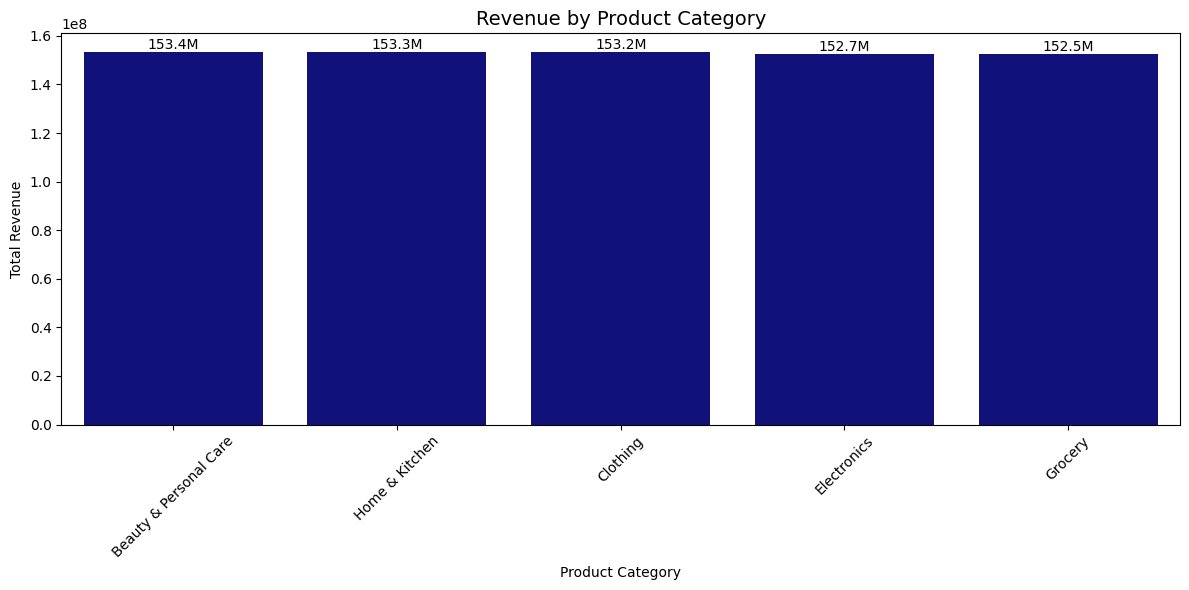

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue by Product Category
category_revenue = (
    df.groupby('ProductCategory')['Total']
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values,
    color='darkblue'
)
plt.title('Revenue by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
# Add revenue labels
for i, value in enumerate(category_revenue.values):
    ax.text(
        i,
        value,
        f'{value/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_5962/1918214922.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


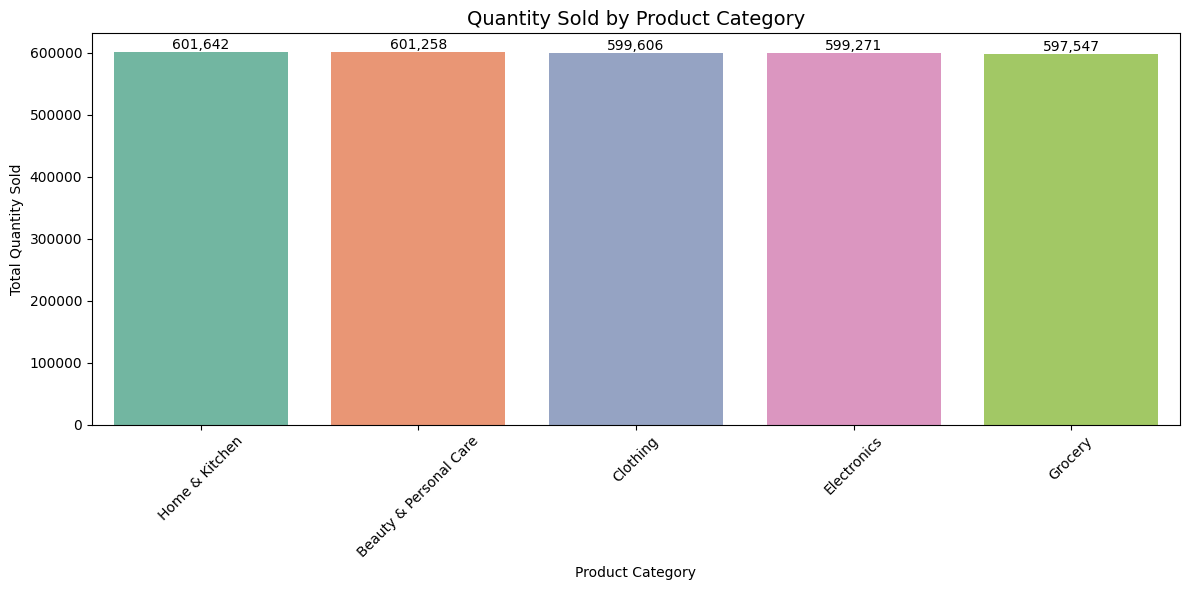

In [ ]:
# Total quantity Sold by Each category
category_quantity = (
    df.groupby('ProductCategory')['Quantity'].sum().sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
colors = sns.color_palette("Set2", len(category_quantity))
ax = sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values,
    palette=colors
)
plt.title('Quantity Sold by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
for i, value in enumerate(category_quantity.values):
    ax.text(
        i,
        value,
        f'{int(value):,}',
        ha='center',
        va='bottom'
    )
plt.tight_layout()
plt.show()

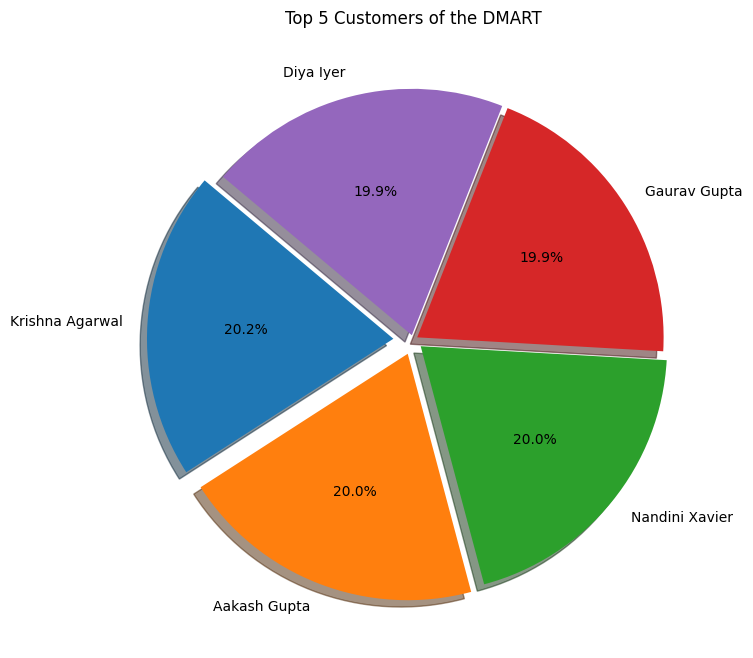

In [ ]:
import matplotlib.pyplot as plt
# Top 5 customers by spending
top_customers = (
    df.groupby('FullName')['Total']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)
plt.figure(figsize=(8,8))
explode = [0.08, 0.06, 0.04, 0.02, 0.02]
plt.pie(
    top_customers.values,
    labels=top_customers.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)
plt.title('Top 5 Customers of the DMART')
plt.show()

   Month_Year        Total
0     2023-01  32230066.19
1     2023-02  28823263.05
2     2023-03  32120556.55
3     2023-04  30955594.52
4     2023-05  32069583.27
5     2023-06  30997849.25
6     2023-07  31983820.98
7     2023-08  31878454.96
8     2023-09  30865306.32
9     2023-10  32167690.07
10    2023-11  31108855.36
11    2023-12  32125221.42
12    2024-01  31964104.48
13    2024-02  29839652.70
14    2024-03  31756582.04
15    2024-04  31342217.90
16    2024-05  32327866.05
17    2024-06  30849465.84
18    2024-07  32334673.93
19    2024-08  32099123.41
20    2024-09  31237862.73
21    2024-10  32048468.39
22    2024-11  30927635.92
23    2024-12  32087889.16
24    2025-01   8952814.90


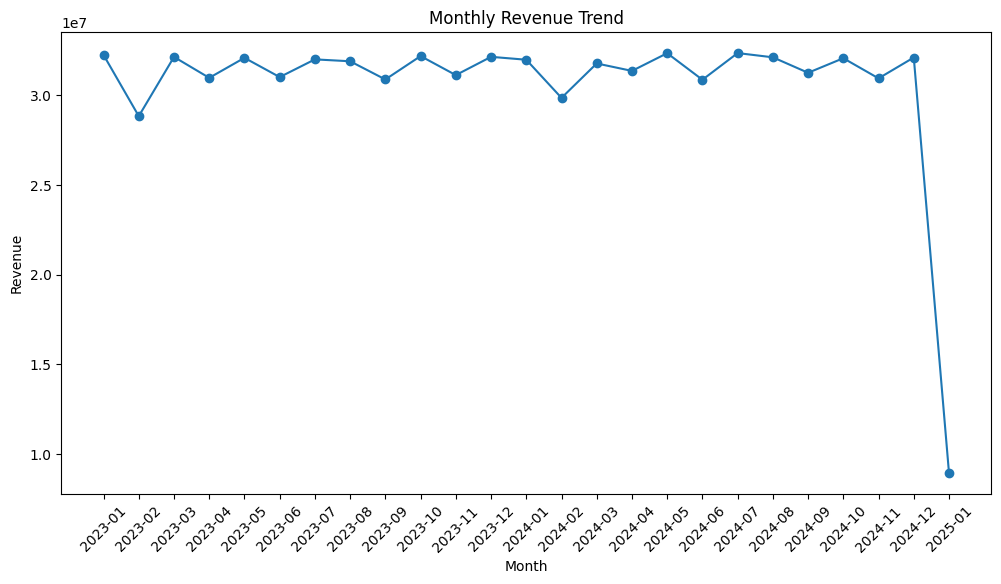

In [ ]:
import matplotlib.pyplot as plt
df['Date_'] = pd.to_datetime(df['Date_'])
df['Month_Year'] = df['Date_'].dt.to_period('M')
monthly_revenue = (
    df.groupby('Month_Year')['Total']
      .sum()
      .reset_index()
)
print(monthly_revenue)
plt.figure(figsize=(12,6))
plt.plot(
    monthly_revenue['Month_Year'].astype(str),
    monthly_revenue['Total'],
    marker='o'
)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()